# **AUTOMATIC DETECTION OF LEARNING STYLE**


In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df = pd.read_csv('final_Data_projec.csv')

In [ ]:
df

,Div,ROLL. NO.,NAME,C_Prog A1,C_Prog A2,C_Prog A3,C_Prog A4,C_Prog A5,C_Prog A6,C_Prog A7,...,preInsem_FYE221006Fundamentals_of_Electrical_Engg.\n(Out of 20),preInsem _FYE221010_Programming_in_C\n(Out of 25),12th_Marks(PCM_Percentage),CET_Percent,FEE_learnico1,FEE_Learnico2,FEE_TW_learnico,Insem_Total,insem_percent,Learner_Type
0,B,1,Agrawal Vedant R,28,25,25,26,25,26,24,...,7,19,57.67,85.50236,9,7,3.0,56,65.882353,AVERAGE
1,B,2,Aher Rohit K,25,25,21,26,25,26,27,...,13,21,64.67,82.61889,8,7,3.0,68,80.000000,FAST
2,B,3,Bagul Monali B,28,25,23,22,25,24,26,...,5,12,50.67,24.21465,8,7,3.0,42,49.411765,AVERAGE
3,B,4,Bari Payal G,21,24,25,23,25,24,23,...,12,15,86.33,82.97091,7,7,3.0,65,76.470588,FAST
4,B,5,Bhavar Hrushikesh R,21,25,24,24,26,25,24,...,1,4,43.67,13.39211,6,0,1.0,18,21.176471,SLOW
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
132,A,68,Trivedi Anurag S,24,17,17,22,17,20,22,...,0,10,51.67,56.00000,0,0,0.0,22,25.882353,SLOW
133,A,69,Vaidya Anjas P,23,26,25,25,24,25,25,...,15,11,56.33,84.56000,0,0,0.0,54,63.529412,AVERAGE
134,A,70,Wagh Kiran R,25,24,25,22,23,23,24,...,11,14,86.33,85.67000,0,0,0.0,56,65.882353,AVERAGE
135,A,71,Wagh Sneha S,25,24,26,25,25,23,25,...,3,8,69.33,65.78000,0,0,0.0,33,38.823529,SLOW


In [ ]:
df.isnull().any()

,0
Div,False
ROLL. NO.,False
NAME,False
C_Prog A1,False
C_Prog A2,False
C_Prog A3,False
C_Prog A4,False
C_Prog A5,False
C_Prog A6,False
C_Prog A7,False


In [ ]:
 df. columns. values

array(['Div', 'ROLL. NO.', 'NAME', 'C_Prog A1', 'C_Prog A2', 'C_Prog A3',
       'C_Prog A4', 'C_Prog A5', 'C_Prog A6', 'C_Prog A7', 'C_Prog A8',
       'Total', 'TW_out_of_50', 'CCE 1 ', 'CCE 2', 'CCE 3', 'CCE 4',
       'CCE 5', 'CCE 6', 'CCE 7', 'CCE 8', 'CCE 9', 'TOTAL',
       'TW_out_of_25', 'TW (25)', 'CCE (20)', 'L1', 'L2', 'L3', 'Total.1',
       'A1', 'General_Merit_No.', 'Psycometric_Tests(out_of_30)',
       'preInsem_FYE221001_Applied_Mathematics-I(Out_of_20)',
       'preInsem_FYE221006Fundamentals_of_Electrical_Engg.\\n(Out of 20)',
       'preInsem _FYE221010_Programming_in_C\\n(Out of 25)',
       '12th_Marks(PCM_Percentage)', 'CET_Percent', 'FEE_learnico1',
       'FEE_Learnico2', 'FEE_TW_learnico', 'Insem_Total', 'insem_percent',
       'Learner_Type'], dtype=object)

In [ ]:
df = df.rename(columns={'Roll No': 'Roll_No'})

In [ ]:
df = df.rename(columns={'Psycometric_Tests(out_of_30)': 'Psycometric_Tests'})

In [ ]:
df = df.rename(columns={'preInsem_FYE221001_Applied_Mathematics-I(Out_of_20)': 'Pre_Applied_Mathematics_I'})

In [ ]:
#df = df.rename(columns={'Insem_FYE221005_Applied Chemistry(Out_of_20)': 'Pre_Applied_Chemistry'})

In [ ]:
df = df.rename(columns={'preInsem_FYE221006Fundamentals_of_Electrical_Engg.\\n(Out of 20)': 'Pre_Fundamentals_of_Electrical_Engg'})

In [ ]:
df = df.rename(columns={'12th_Marks(PCM_Percentage)': 'HSC'})

In [ ]:
df = df.rename(columns={'preInsem _FYE221010_Programming_in_C\\n(Out of 25)': 'Pre_Programming_in_C'})

In [ ]:
df = df.rename(columns={'CET Percent': 'CET_Percent'})

In [ ]:
df.tail(9)

,Div,ROLL. NO.,NAME,C_Prog A1,C_Prog A2,C_Prog A3,C_Prog A4,C_Prog A5,C_Prog A6,C_Prog A7,...,Pre_Fundamentals_of_Electrical_Engg,Pre_Programming_in_C,HSC,CET_Percent,FEE_learnico1,FEE_Learnico2,FEE_TW_learnico,Insem_Total,insem_percent,Learner_Type
128,A,64,Tambat Swara M,25,25,26,28,27,26,25,...,6,20,45.00,45.65,4,4,3.2,62,72.941176,FAST
129,A,65,Thakare Tejal C,24,20,25,26,25,25,24,...,11,15,75.33,75.48,3,3,2.4,53,62.352941,AVERAGE
130,A,66,Tile Pranjal D,23,24,25,28,26,26,25,...,19,21,79.67,87.59,3,3,2.4,79,92.941176,FAST
131,A,67,Tisgaonkar Sarthak S,25,25,20,23,24,23,23,...,17,16,65.00,71.04,3,3,2.4,66,77.647059,FAST
132,A,68,Trivedi Anurag S,24,17,17,22,17,20,22,...,0,10,51.67,56.00,0,0,0.0,22,25.882353,SLOW
133,A,69,Vaidya Anjas P,23,26,25,25,24,25,25,...,15,11,56.33,84.56,0,0,0.0,54,63.529412,AVERAGE
134,A,70,Wagh Kiran R,25,24,25,22,23,23,24,...,11,14,86.33,85.67,0,0,0.0,56,65.882353,AVERAGE
135,A,71,Wagh Sneha S,25,24,26,25,25,23,25,...,3,8,69.33,65.78,0,0,0.0,33,38.823529,SLOW
136,A,72,Waikande Pratiksha b,24,25,20,25,20,23,25,...,3,6,42.67,45.76,0,0,0.0,28,32.941176,SLOW


In [ ]:
df.shape


(137, 44)

In [ ]:
df. columns. values


array(['Div', 'ROLL. NO.', 'NAME', 'C_Prog A1', 'C_Prog A2', 'C_Prog A3',
       'C_Prog A4', 'C_Prog A5', 'C_Prog A6', 'C_Prog A7', 'C_Prog A8',
       'Total', 'TW_out_of_50', 'CCE 1 ', 'CCE 2', 'CCE 3', 'CCE 4',
       'CCE 5', 'CCE 6', 'CCE 7', 'CCE 8', 'CCE 9', 'TOTAL',
       'TW_out_of_25', 'TW (25)', 'CCE (20)', 'L1', 'L2', 'L3', 'Total.1',
       'A1', 'General_Merit_No.', 'Psycometric_Tests',
       'Pre_Applied_Mathematics_I', 'Pre_Fundamentals_of_Electrical_Engg',
       'Pre_Programming_in_C', 'HSC', 'CET_Percent', 'FEE_learnico1',
       'FEE_Learnico2', 'FEE_TW_learnico', 'Insem_Total', 'insem_percent',
       'Learner_Type'], dtype=object)

In [ ]:
df = df.rename(columns={'\nLearner_Type': 'Learner_Type'})

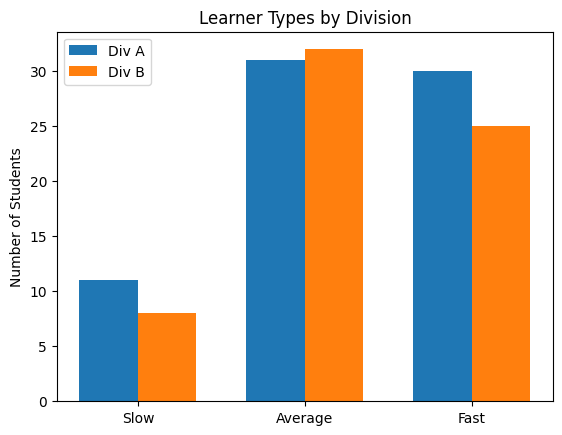

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Combined data for div A and B
div_a_slow = 11
div_a_avg = 31
div_a_fast = 30
div_b_slow = 8
div_b_avg = 32
div_b_fast = 25

# Create a bar chart
labels = ['Slow', 'Average', 'Fast']
div_a_data = [div_a_slow, div_a_avg, div_a_fast]
div_b_data = [div_b_slow, div_b_avg, div_b_fast]
x = np.arange(len(labels))
width = 0.35
fig, ax = plt.subplots()
rects1 = ax.bar(x - width/2, div_a_data, width, label='Div A')
rects2 = ax.bar(x + width/2, div_b_data, width, label='Div B')

# Add labels and title
ax.set_ylabel('Number of Students')
ax.set_title('Learner Types by Division')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

plt.show()


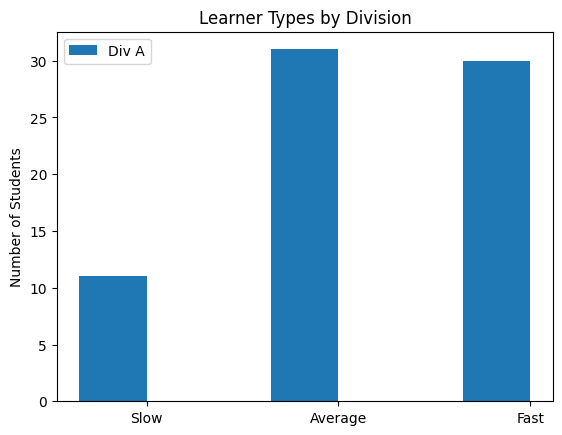

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Combined data for div A and B
div_a_slow = 11
div_a_avg = 31
div_a_fast = 30

# Create a bar chart
labels = ['Slow', 'Average', 'Fast']
div_a_data = [div_a_slow, div_a_avg, div_a_fast]

x = np.arange(len(labels))
width = 0.35
fig, ax = plt.subplots()
rects1 = ax.bar(x - width/2, div_a_data, width, label='Div A')


# Add labels and title
ax.set_ylabel('Number of Students')
ax.set_title('Learner Types by Division')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

plt.show()


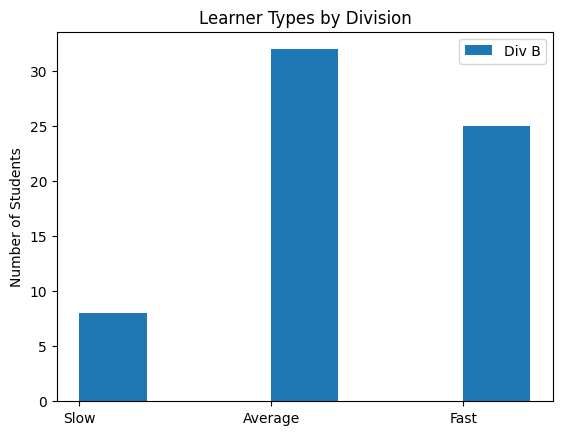

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

div_b_slow = 8
div_b_avg = 32
div_b_fast = 25

# Create a bar chart
labels = ['Slow', 'Average', 'Fast']

div_b_data = [div_b_slow, div_b_avg, div_b_fast]
x = np.arange(len(labels))
width = 0.35
fig, ax = plt.subplots()

rects2 = ax.bar(x + width/2, div_b_data, width, label='Div B')

# Add labels and title
ax.set_ylabel('Number of Students')
ax.set_title('Learner Types by Division')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

plt.show()


In [ ]:
# replace 'Division_A' with the actual division name
division = 'A'

# filter the dataframe to only include rows where 'Learner_Type' is 'slow' and 'Div' is the division of interest
division_slow_learners = df[(df['Learner_Type'] == 'SLOW') & (df['Div'] == division)]

# find the total number of slow learners in the division
total_slow_learners = len(division_slow_learners)
total_slow_learners

11

In [ ]:
# replace 'Division_A' with the actual division name
division = 'A'

# filter the dataframe to only include rows where 'Learner_Type' is 'slow' and 'Div' is the division of interest
division_slow_learners = df[(df['Learner_Type'] == 'FAST') & (df['Div'] == division)]

# find the total number of slow learners in the division
total_slow_learners = len(division_slow_learners)
total_slow_learners

31

In [ ]:
# replace 'Division_A' with the actual division name
division = 'A'

# filter the dataframe to only include rows where 'Learner_Type' is 'slow' and 'Div' is the division of interest
division_slow_learners = df[(df['Learner_Type'] == 'AVERAGE') & (df['Div'] == division)]

# find the total number of slow learners in the division
total_slow_learners = len(division_slow_learners)
total_slow_learners

30

In [ ]:
# replace 'Division_A' with the actual division name
division = 'B'

# filter the dataframe to only include rows where 'Learner_Type' is 'slow' and 'Div' is the division of interest
division_slow_learners = df[(df['Learner_Type'] == 'FAST') & (df['Div'] == division)]

# find the total number of slow learners in the division
total_slow_learners = len(division_slow_learners)
total_slow_learners

32

In [ ]:
# replace 'Division_A' with the actual division name
division = 'B'

# filter the dataframe to only include rows where 'Learner_Type' is 'slow' and 'Div' is the division of interest
division_slow_learners = df[(df['Learner_Type'] == 'SLOW') & (df['Div'] == division)]

# find the total number of slow learners in the division
total_slow_learners = len(division_slow_learners)
total_slow_learners

8

In [ ]:
# replace 'Division_A' with the actual division name
division = 'B'

# filter the dataframe to only include rows where 'Learner_Type' is 'slow' and 'Div' is the division of interest
division_slow_learners = df[(df['Learner_Type'] == 'AVERAGE') & (df['Div'] == division)]

# find the total number of slow learners in the division
total_slow_learners = len(division_slow_learners)
total_slow_learners

25

# **PREPROCESSING OF DATASET**

In [ ]:
df1=df.drop(["Div","ROLL. NO.","Insem_Total","insem_percent"],axis=1)
df1

,NAME,C_Prog A1,C_Prog A2,C_Prog A3,C_Prog A4,C_Prog A5,C_Prog A6,C_Prog A7,C_Prog A8,Total,...,Psycometric_Tests,Pre_Applied_Mathematics_I,Pre_Fundamentals_of_Electrical_Engg,Pre_Programming_in_C,HSC,CET_Percent,FEE_learnico1,FEE_Learnico2,FEE_TW_learnico,Learner_Type
0,Agrawal Vedant R,28,25,25,26,25,26,24,26,205,...,15,17,7,19,57.67,85.50236,9,7,3.0,AVERAGE
1,Aher Rohit K,25,25,21,26,25,26,27,27,202,...,13,17,13,21,64.67,82.61889,8,7,3.0,FAST
2,Bagul Monali B,28,25,23,22,25,24,26,25,198,...,21,10,5,12,50.67,24.21465,8,7,3.0,AVERAGE
3,Bari Payal G,21,24,25,23,25,24,23,26,191,...,14,20,12,15,86.33,82.97091,7,7,3.0,FAST
4,Bhavar Hrushikesh R,21,25,24,24,26,25,24,24,193,...,16,5,1,4,43.67,13.39211,6,0,1.0,SLOW
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
132,Trivedi Anurag S,24,17,17,22,17,20,22,20,159,...,18,4,0,10,51.67,56.00000,0,0,0.0,SLOW
133,Vaidya Anjas P,23,26,25,25,24,25,25,25,198,...,15,15,15,11,56.33,84.56000,0,0,0.0,AVERAGE
134,Wagh Kiran R,25,24,25,22,23,23,24,24,190,...,8,14,11,14,86.33,85.67000,0,0,0.0,AVERAGE
135,Wagh Sneha S,25,24,26,25,25,23,25,23,196,...,12,11,3,8,69.33,65.78000,0,0,0.0,SLOW


In [ ]:
df2=df1.drop(["General_Merit_No.","NAME","TW (25)"],axis=1)
df2

,C_Prog A1,C_Prog A2,C_Prog A3,C_Prog A4,C_Prog A5,C_Prog A6,C_Prog A7,C_Prog A8,Total,TW_out_of_50,...,Psycometric_Tests,Pre_Applied_Mathematics_I,Pre_Fundamentals_of_Electrical_Engg,Pre_Programming_in_C,HSC,CET_Percent,FEE_learnico1,FEE_Learnico2,FEE_TW_learnico,Learner_Type
0,28,25,25,26,25,26,24,26,205,43,...,15,17,7,19,57.67,85.50236,9,7,3.0,AVERAGE
1,25,25,21,26,25,26,27,27,202,42,...,13,17,13,21,64.67,82.61889,8,7,3.0,FAST
2,28,25,23,22,25,24,26,25,198,41,...,21,10,5,12,50.67,24.21465,8,7,3.0,AVERAGE
3,21,24,25,23,25,24,23,26,191,40,...,14,20,12,15,86.33,82.97091,7,7,3.0,FAST
4,21,25,24,24,26,25,24,24,193,40,...,16,5,1,4,43.67,13.39211,6,0,1.0,SLOW
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
132,24,17,17,22,17,20,22,20,159,33,...,18,4,0,10,51.67,56.00000,0,0,0.0,SLOW
133,23,26,25,25,24,25,25,25,198,41,...,15,15,15,11,56.33,84.56000,0,0,0.0,AVERAGE
134,25,24,25,22,23,23,24,24,190,40,...,8,14,11,14,86.33,85.67000,0,0,0.0,AVERAGE
135,25,24,26,25,25,23,25,23,196,41,...,12,11,3,8,69.33,65.78000,0,0,0.0,SLOW


In [ ]:
df2

,C_Prog A1,C_Prog A2,C_Prog A3,C_Prog A4,C_Prog A5,C_Prog A6,C_Prog A7,C_Prog A8,Total,TW_out_of_50,...,Psycometric_Tests,Pre_Applied_Mathematics_I,Pre_Fundamentals_of_Electrical_Engg,Pre_Programming_in_C,HSC,CET_Percent,FEE_learnico1,FEE_Learnico2,FEE_TW_learnico,Learner_Type
0,28,25,25,26,25,26,24,26,205,43,...,15,17,7,19,57.67,85.50236,9,7,3.0,AVERAGE
1,25,25,21,26,25,26,27,27,202,42,...,13,17,13,21,64.67,82.61889,8,7,3.0,FAST
2,28,25,23,22,25,24,26,25,198,41,...,21,10,5,12,50.67,24.21465,8,7,3.0,AVERAGE
3,21,24,25,23,25,24,23,26,191,40,...,14,20,12,15,86.33,82.97091,7,7,3.0,FAST
4,21,25,24,24,26,25,24,24,193,40,...,16,5,1,4,43.67,13.39211,6,0,1.0,SLOW
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
132,24,17,17,22,17,20,22,20,159,33,...,18,4,0,10,51.67,56.00000,0,0,0.0,SLOW
133,23,26,25,25,24,25,25,25,198,41,...,15,15,15,11,56.33,84.56000,0,0,0.0,AVERAGE
134,25,24,25,22,23,23,24,24,190,40,...,8,14,11,14,86.33,85.67000,0,0,0.0,AVERAGE
135,25,24,26,25,25,23,25,23,196,41,...,12,11,3,8,69.33,65.78000,0,0,0.0,SLOW


In [ ]:
df2.describe()

,C_Prog A1,C_Prog A2,C_Prog A3,C_Prog A4,C_Prog A5,C_Prog A6,C_Prog A7,C_Prog A8,Total,TW_out_of_50,...,A1,Psycometric_Tests,Pre_Applied_Mathematics_I,Pre_Fundamentals_of_Electrical_Engg,Pre_Programming_in_C,HSC,CET_Percent,FEE_learnico1,FEE_Learnico2,FEE_TW_learnico
count,137.000000,137.000000,137.000000,137.000000,137.000000,137.000000,137.000000,137.000000,137.000000,137.000000,...,137.000000,137.000000,137.000000,137.000000,137.000000,137.000000,137.000000,137.000000,137.000000,137.000000
mean,24.905109,24.021898,23.540146,25.175182,24.065693,24.766423,24.562044,24.781022,195.817518,40.824818,...,15.927007,15.496350,13.211679,10.000000,14.839416,66.859197,75.495107,4.824818,4.189781,2.474453
std,4.211125,3.804926,3.438567,3.307518,3.270196,3.049259,3.210418,3.086296,21.167476,4.400698,...,3.216765,4.454218,5.018247,5.333027,5.221891,12.686607,18.367573,3.060416,2.396483,1.047969
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,6.000000,0.000000,0.000000,2.000000,42.670000,1.962868,0.000000,0.000000,0.000000
25%,24.000000,24.000000,23.000000,24.000000,23.000000,23.000000,23.000000,23.000000,191.000000,40.000000,...,15.000000,13.000000,10.000000,6.000000,11.000000,56.330000,70.000000,3.000000,3.000000,2.000000
50%,25.000000,25.000000,24.000000,26.000000,25.000000,25.000000,25.000000,25.000000,197.000000,41.000000,...,16.000000,15.000000,15.000000,9.000000,15.000000,67.940000,82.618890,4.000000,4.000000,3.000000
75%,27.000000,26.000000,25.000000,27.000000,26.000000,26.000000,26.000000,26.000000,206.000000,43.000000,...,18.000000,18.000000,17.000000,15.000000,19.000000,76.330000,86.800000,7.000000,6.000000,3.200000
max,30.000000,28.000000,28.000000,29.000000,29.000000,30.000000,30.000000,30.000000,223.000000,46.000000,...,20.000000,30.000000,20.000000,20.000000,25.000000,98.000000,98.100000,10.000000,8.000000,4.000000


# TRAINING AND TESTING

In [ ]:
x = df2.drop(['Learner_Type'], axis = 1)
X=x.values
y = df2['Learner_Type']

In [ ]:
df2.isnull().sum()

,0
C_Prog A1,0
C_Prog A2,0
C_Prog A3,0
C_Prog A4,0
C_Prog A5,0
C_Prog A6,0
C_Prog A7,0
C_Prog A8,0
Total,0
TW_out_of_50,0


In [ ]:
df2.columns.values


array(['C_Prog A1', 'C_Prog A2', 'C_Prog A3', 'C_Prog A4', 'C_Prog A5',
       'C_Prog A6', 'C_Prog A7', 'C_Prog A8', 'Total', 'TW_out_of_50',
       'CCE 1 ', 'CCE 2', 'CCE 3', 'CCE 4', 'CCE 5', 'CCE 6', 'CCE 7',
       'CCE 8', 'CCE 9', 'TOTAL', 'TW_out_of_25', 'CCE (20)', 'L1', 'L2',
       'L3', 'Total.1', 'A1', 'Psycometric_Tests',
       'Pre_Applied_Mathematics_I', 'Pre_Fundamentals_of_Electrical_Engg',
       'Pre_Programming_in_C', 'HSC', 'CET_Percent', 'FEE_learnico1',
       'FEE_Learnico2', 'FEE_TW_learnico', 'Learner_Type'], dtype=object)

In [ ]:

df2.dropna(axis=1,inplace=True)
df2

,C_Prog A1,C_Prog A2,C_Prog A3,C_Prog A4,C_Prog A5,C_Prog A6,C_Prog A7,C_Prog A8,Total,TW_out_of_50,...,Psycometric_Tests,Pre_Applied_Mathematics_I,Pre_Fundamentals_of_Electrical_Engg,Pre_Programming_in_C,HSC,CET_Percent,FEE_learnico1,FEE_Learnico2,FEE_TW_learnico,Learner_Type
0,28,25,25,26,25,26,24,26,205,43,...,15,17,7,19,57.67,85.50236,9,7,3.0,AVERAGE
1,25,25,21,26,25,26,27,27,202,42,...,13,17,13,21,64.67,82.61889,8,7,3.0,FAST
2,28,25,23,22,25,24,26,25,198,41,...,21,10,5,12,50.67,24.21465,8,7,3.0,AVERAGE
3,21,24,25,23,25,24,23,26,191,40,...,14,20,12,15,86.33,82.97091,7,7,3.0,FAST
4,21,25,24,24,26,25,24,24,193,40,...,16,5,1,4,43.67,13.39211,6,0,1.0,SLOW
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
132,24,17,17,22,17,20,22,20,159,33,...,18,4,0,10,51.67,56.00000,0,0,0.0,SLOW
133,23,26,25,25,24,25,25,25,198,41,...,15,15,15,11,56.33,84.56000,0,0,0.0,AVERAGE
134,25,24,25,22,23,23,24,24,190,40,...,8,14,11,14,86.33,85.67000,0,0,0.0,AVERAGE
135,25,24,26,25,25,23,25,23,196,41,...,12,11,3,8,69.33,65.78000,0,0,0.0,SLOW


#TRAINING WITH DIFFERENT MODEL

In [ ]:
#decision tree

#decision tree



In [ ]:

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size = 0.20, random_state = 0)


In [ ]:
from sklearn.tree import DecisionTreeClassifier
classifier = DecisionTreeClassifier(criterion='entropy',max_depth=3, random_state=42)
classifier.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=42)

In [ ]:
predictions1 = classifier.predict(X_test)
predictions1

array(['FAST', 'FAST', 'FAST', 'FAST', 'FAST', 'FAST', 'FAST', 'FAST',
       'AVERAGE', 'FAST', 'FAST', 'SLOW', 'SLOW', 'AVERAGE', 'FAST',
       'SLOW', 'AVERAGE', 'AVERAGE', 'AVERAGE', 'SLOW', 'AVERAGE',
       'AVERAGE', 'FAST', 'AVERAGE', 'FAST', 'AVERAGE', 'FAST', 'FAST'],
      dtype=object)

In [ ]:
#lets see the actual and predicted value side by side

#numpy.vstack() function is used to stack the sequence of input arrays vertically to make a single array.
y_compare = np.vstack((y_test,predictions1)).T

#actual value on the left side and predicted value on the right hand side
#printing the top 5 values
y_compare[:22,:]

array([['FAST', 'FAST'],
       ['AVERAGE', 'FAST'],
       ['AVERAGE', 'FAST'],
       ['FAST', 'FAST'],
       ['FAST', 'FAST'],
       ['AVERAGE', 'FAST'],
       ['FAST', 'FAST'],
       ['FAST', 'FAST'],
       ['AVERAGE', 'AVERAGE'],
       ['FAST', 'FAST'],
       ['FAST', 'FAST'],
       ['SLOW', 'SLOW'],
       ['SLOW', 'SLOW'],
       ['AVERAGE', 'AVERAGE'],
       ['FAST', 'FAST'],
       ['SLOW', 'SLOW'],
       ['FAST', 'AVERAGE'],
       ['AVERAGE', 'AVERAGE'],
       ['FAST', 'AVERAGE'],
       ['SLOW', 'SLOW'],
       ['AVERAGE', 'AVERAGE'],
       ['AVERAGE', 'AVERAGE']], dtype=object)

In [ ]:
# Making the Confusion Matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test,predictions1)
print(cm)

#finding accuracy from the confusion matrix.
a = cm.shape
corrPred = 0
falsePred = 0

for row in range(a[0]):
    for c in range(a[1]):
        if row == c:
             corrPred  +=cm[row,c]
        else:
            falsePred += cm[row,c]
print('Correct predictions: ', corrPred)
print('False predictions', falsePred)
kernelPolyAccuracy = corrPred/(cm.sum())
print ('Accuracy of the Decision tree Clasification is: ', (corrPred/(cm.sum()))*100)

[[ 7  4  0]
 [ 2 11  0]
 [ 0  0  4]]
Correct predictions:  22
False predictions 6
Accuracy of the Decision tree Clasification is:  78.57142857142857


In [ ]:
j9=classifier.predict([[28,	25,	23	,22	,25	,24,	26,	25,	198	,41	,10,	10,	14,	4.5	,6,	9.5,	9,	6,	8,	77	,21.38888889	,	17,	4	,10	,6,	8	,16	,	21	,10	,5,	12,	50.67,	24.21465,	8,	7	,3]])
j9

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array(['AVERAGE'], dtype=object)

In [ ]:
#random forest

#random forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rfc = RandomForestClassifier(bootstrap=True,
                              max_depth=10,
                              max_features='sqrt',
                              random_state=1)

rfc.fit(X, y)

RandomForestClassifier(max_depth=10, random_state=1)

In [ ]:
predictions = rfc.predict(X_test)
predictions

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


array(['FAST', 'AVERAGE', 'AVERAGE', 'FAST', 'FAST', 'AVERAGE', 'FAST',
       'FAST', 'AVERAGE', 'FAST', 'FAST', 'SLOW', 'SLOW', 'AVERAGE',
       'FAST', 'SLOW', 'FAST', 'AVERAGE', 'FAST', 'SLOW', 'AVERAGE',
       'AVERAGE', 'FAST', 'AVERAGE', 'AVERAGE', 'AVERAGE', 'FAST', 'FAST'],
      dtype=object)

In [ ]:
x

,C_Prog A1,C_Prog A2,C_Prog A3,C_Prog A4,C_Prog A5,C_Prog A6,C_Prog A7,C_Prog A8,Total,TW_out_of_50,...,A1,Psycometric_Tests,Pre_Applied_Mathematics_I,Pre_Fundamentals_of_Electrical_Engg,Pre_Programming_in_C,HSC,CET_Percent,FEE_learnico1,FEE_Learnico2,FEE_TW_learnico
0,28,25,25,26,25,26,24,26,205,43,...,18,15,17,7,19,57.67,85.50236,9,7,3.0
1,25,25,21,26,25,26,27,27,202,42,...,12,13,17,13,21,64.67,82.61889,8,7,3.0
2,28,25,23,22,25,24,26,25,198,41,...,16,21,10,5,12,50.67,24.21465,8,7,3.0
3,21,24,25,23,25,24,23,26,191,40,...,18,14,20,12,15,86.33,82.97091,7,7,3.0
4,21,25,24,24,26,25,24,24,193,40,...,16,16,5,1,4,43.67,13.39211,6,0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
132,24,17,17,22,17,20,22,20,159,33,...,12,18,4,0,10,51.67,56.00000,0,0,0.0
133,23,26,25,25,24,25,25,25,198,41,...,16,15,15,15,11,56.33,84.56000,0,0,0.0
134,25,24,25,22,23,23,24,24,190,40,...,18,8,14,11,14,86.33,85.67000,0,0,0.0
135,25,24,26,25,25,23,25,23,196,41,...,19,12,11,3,8,69.33,65.78000,0,0,0.0


In [ ]:
#lets see the actual and predicted value side by side

#numpy.vstack() function is used to stack the sequence of input arrays vertically to make a single array.
y_compare = np.vstack((y_test,predictions)).T

#actual value on the left side and predicted value on the right hand side
#printing the top 5 values
y_compare[:22,:]

array([['FAST', 'FAST'],
       ['AVERAGE', 'AVERAGE'],
       ['AVERAGE', 'AVERAGE'],
       ['FAST', 'FAST'],
       ['FAST', 'FAST'],
       ['AVERAGE', 'AVERAGE'],
       ['FAST', 'FAST'],
       ['FAST', 'FAST'],
       ['AVERAGE', 'AVERAGE'],
       ['FAST', 'FAST'],
       ['FAST', 'FAST'],
       ['SLOW', 'SLOW'],
       ['SLOW', 'SLOW'],
       ['AVERAGE', 'AVERAGE'],
       ['FAST', 'FAST'],
       ['SLOW', 'SLOW'],
       ['FAST', 'FAST'],
       ['AVERAGE', 'AVERAGE'],
       ['FAST', 'FAST'],
       ['SLOW', 'SLOW'],
       ['AVERAGE', 'AVERAGE'],
       ['AVERAGE', 'AVERAGE']], dtype=object)

In [ ]:
# Making the Confusion Matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, predictions)
print(cm)


[[11  0  0]
 [ 0 13  0]
 [ 0  0  4]]


In [ ]:
# Making the Confusion Matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test,predictions)
print(cm)

#finding accuracy from the confusion matrix.
a = cm.shape
corrPred = 0
falsePred = 0

for row in range(a[0]):
    for c in range(a[1]):
        if row == c:
             corrPred  +=cm[row,c]
        else:
            falsePred += cm[row,c]
print('Correct predictions: ', corrPred)
print('False predictions', falsePred)
kernelPolyAccuracy = corrPred/(cm.sum())
print ('Accuracy of the random forest Clasification is: ', (corrPred/(cm.sum()))*100)

[[11  0  0]
 [ 0 13  0]
 [ 0  0  4]]
Correct predictions:  28
False predictions 0
Accuracy of the random forest Clasification is:  100.0


In [ ]:
#svm classifier

#svm classifier


In [ ]:
pip install streamlit


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 90.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 88.6 MB/s eta 0:00:00


In [ ]:
from sklearn.multiclass import OneVsOneClassifier
from sklearn.svm import SVC

svc = SVC()
model = OneVsOneClassifier(svc)
model.fit(X_train, y_train)
# Use the modified X_df for prediction
yhat = model.predict(X_test)
yhat


array(['FAST', 'FAST', 'FAST', 'FAST', 'FAST', 'FAST', 'FAST', 'FAST',
       'FAST', 'FAST', 'FAST', 'AVERAGE', 'AVERAGE', 'FAST', 'FAST',
       'FAST', 'FAST', 'AVERAGE', 'FAST', 'AVERAGE', 'FAST', 'FAST',
       'FAST', 'FAST', 'AVERAGE', 'FAST', 'FAST', 'FAST'], dtype=object)

In [ ]:
predictions2 = model.predict(X_test)
predictions2

array(['FAST', 'FAST', 'FAST', 'FAST', 'FAST', 'FAST', 'FAST', 'FAST',
       'FAST', 'FAST', 'FAST', 'AVERAGE', 'AVERAGE', 'FAST', 'FAST',
       'FAST', 'FAST', 'AVERAGE', 'FAST', 'AVERAGE', 'FAST', 'FAST',
       'FAST', 'FAST', 'AVERAGE', 'FAST', 'FAST', 'FAST'], dtype=object)

In [ ]:
# Making the Confusion Matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test,predictions2)
print(cm)

#finding accuracy from the confusion matrix.
a = cm.shape
corrPred = 0
falsePred = 0

for row in range(a[0]):
    for c in range(a[1]):
        if row == c:
             corrPred  +=cm[row,c]
        else:
            falsePred += cm[row,c]
print('Correct predictions: ', corrPred)
print('False predictions', falsePred)
kernelPolyAccuracy = corrPred/(cm.sum())
print ('Accuracy of the SVM Clasification is: ', (corrPred/(cm.sum()))*100)

[[ 2  9  0]
 [ 0 13  0]
 [ 3  1  0]]
Correct predictions:  15
False predictions 13
Accuracy of the SVM Clasification is:  53.57142857142857


In [ ]:
# Making the Confusion Matrix
from sklearn.metrics import classification_report
cr=classification_report(y_test,yhat)
print(cr)

              precision    recall  f1-score   support

     AVERAGE       0.40      0.18      0.25        11
        FAST       0.57      1.00      0.72        13
        SLOW       0.00      0.00      0.00         4

    accuracy                           0.54        28
   macro avg       0.32      0.39      0.32        28
weighted avg       0.42      0.54      0.43        28



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


#KNN

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
X_train, X_test, y_train, y_test = train_test_split(X_train, y_train,test_size=0.2, random_state = 1)
knn_clf=KNeighborsClassifier()
knn_clf.fit(X_train,y_train)
ypred=knn_clf.predict(X_test) #These are the predicted output values

In [ ]:
# Making the Confusion Matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test,ypred )
print(cm)

#finding accuracy from the confusion matrix.
a = cm.shape
corrPred = 0
falsePred = 0

for row in range(a[0]):
    for c in range(a[1]):
        if row == c:
             corrPred  +=cm[row,c]
        else:
            falsePred += cm[row,c]
print('Correct predictions: ', corrPred)
print('False predictions', falsePred)
kernelPolyAccuracy = corrPred/(cm.sum())
print ('Accuracy of the knn Clasification is: ', (corrPred/(cm.sum()))*100)

[[7 2 1]
 [2 7 0]
 [3 0 0]]
Correct predictions:  14
False predictions 8
Accuracy of the knn Clasification is:  63.63636363636363


In [ ]:
import pickle
with open('model.pkl', 'wb') as file:
    pickle.dump(rfc, file)

#TESTING


In [ ]:
j2=rfc.predict([[28,	25,	23	,22	,25	,24,	26,	25,	198	,41	,10,	10,	14,	4.5	,6,	9.5,	9,	6,	8,	77	,21.38888889	,	17,	4	,10	,6,	8	,16	,	21	,10	,5,	12,	50.67,	24.21465,	8,	7	,3]])
j2

array(['AVERAGE'], dtype=object)

In [ ]:
new1=rfc.predict([[25,	24,	25,	22,	23,	23	,24	,24	,190,	40,	9,	10,	15,	2,	3,	9.5,	6,	6	,9.5,	70,	19,	16,	11,	12,	10,	7,	18,	8,	14,	11,	14,	86.33,	85.67,	0	,0	,0]])
new1

array(['AVERAGE'], dtype=object)

#MODEL DEPLOY


In [ ]:
pip install reportlab


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 28.0 MB/s eta 0:00:00


In [ ]:
# streamlit run app.py


In [ ]:
pip install gradio --upgrade

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 30.7/30.7 MB 67.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.7/61.7 kB 4.5 MB/s eta 0:00:00
  Attempting uninstall: gradio-client
    Found existing installation: gradio_client 2.5.0
    Uninstalling gradio_client-2.5.0:
      Successfully uninstalled gradio_client-2.5.0
  Attempting uninstall: gradio
    Found existing installation: gradio 6.20.0
    Uninstalling gradio-6.20.0:
      Successfully uninstalled gradio-6.20.0


In [ ]:
# import gradio as gr
# import pandas as pd
# import glob
# import os

# def predict(file_obj):
#     df = pd.read_csv(file_obj.name,dtype=str)
#     return df
#     list_of_files = glob.glob('flagged/file_obj/*')
#     latest_file = max(list_of_files, key=os.path.getctime)
#     df = pd.read_csv(latest_file)#read the uploaded file

# def main():
#     io = gr.Interface(predict, ["file"], "dataframe")

#     io.launch()




# if __name__ == "__main__":
#     main()

